In [2]:
import numpy as np
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

/Users/jakubkozak/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [3]:
tickers = ["^GSPC", "^IXIC"]  # S&P 500 and Nasdaq Composite

data = yf.download(
    tickers=tickers,
    period="60d",
    interval="5m",
    auto_adjust=True,
    group_by="ticker",
    progress=True
)

[*********************100%***********************]  2 of 2 completed


In [4]:
# implikowanej
ticker = yf.Ticker("AAPL")
options_chain = ticker.option_chain(ticker.options[0])
print(options_chain.calls[['strike', 'impliedVolatility']])

    strike  impliedVolatility
0    250.0           1.185551
1    255.0           1.689943
2    260.0           0.847658
3    265.0           0.830080
4    275.0           1.201908
5    280.0           0.503911
6    285.0           0.587895
7    290.0           0.592289
8    295.0           0.673343
9    300.0           0.502202
10   305.0           0.237312
11   310.0           0.155526
12   315.0           0.140878
13   320.0           0.167977
14   325.0           0.205086
15   330.0           0.257820
16   335.0           0.316413
17   340.0           0.390631
18   345.0           0.529302


In [5]:
tickers = ["^GSPC", "^IXIC", "^VIX"]

data = yf.download(
    tickers,
    start="2020-01-01",
    end="2025-01-01",
    auto_adjust=True
)

data = data.swaplevel(axis=1).sort_index(axis=1)

[*********************100%***********************]  3 of 3 completed


Price             Close                             High               \
Ticker            ^GSPC        ^IXIC   ^VIX        ^GSPC        ^IXIC   
Date                                                                    
2020-01-02  3257.850098  9092.190430  12.47  3258.139893  9093.429688   
2020-01-03  3234.850098  9020.769531  14.02  3246.149902  9065.759766   
2020-01-06  3246.280029  9071.469727  13.85  3246.840088  9072.410156   
2020-01-07  3237.179932  9068.580078  13.79  3244.909912  9091.929688   
2020-01-08  3253.050049  9129.240234  13.45  3267.070068  9168.889648   

Price                          Low                             Open  \
Ticker           ^VIX        ^GSPC        ^IXIC   ^VIX        ^GSPC   
Date                                                                  
2020-01-02  13.720000  3235.530029  9010.889648  12.42  3244.669922   
2020-01-03  16.200001  3222.340088  8976.429688  13.13  3226.360107   
2020-01-06  16.389999  3214.639893  8943.500000  13.54  3217.550049   
2020-01-07  14.460000  3232.429932  9042.549805  13.39  3241.860107   
2020-01-08  15.240000  3236.669922  9059.379883  12.83  3238.590088   

Price                               Volume                   
Ticker            ^IXIC   ^VIX       ^GSPC       ^IXIC ^VIX  
Date                                                         
2020-01-02  9039.459961  13.46  3459930000  2862700000    0  
2020-01-03  8976.429688  15.01  3484700000  2586520000    0  
2020-01-06  8943.500000  15.45  3702460000  2810450000    0  
2020-01-07  9076.639648  13.84  3435910000  2381740000    0  
2020-01-08  9068.030273  15.16  3726840000  2472620000    0

In [10]:
data
data = data.swaplevel(axis=1).sort_index(axis=1)

In [11]:
def compute_rv(data, ticker):
    # Pobranie danych dla konkretnego tickera z MultiIndex
    df = data[ticker].copy()
    df['log_close'] = np.log(df['Close'])
    df["Ret_1d"] = df["log_close"].diff()
    df["RV_5d"] = df["Ret_1d"].rolling(5).std()
    df["RV_22d"] = df['Ret_1d'].rolling(22).std()
    return df

In [12]:
data.columns

MultiIndex([('^GSPC',  'Close'),
            ('^GSPC',   'High'),
            ('^GSPC',    'Low'),
            ('^GSPC',   'Open'),
            ('^GSPC', 'Volume'),
            ('^IXIC',  'Close'),
            ('^IXIC',   'High'),
            ('^IXIC',    'Low'),
            ('^IXIC',   'Open'),
            ('^IXIC', 'Volume'),
            ( '^VIX',  'Close'),
            ( '^VIX',   'High'),
            ( '^VIX',    'Low'),
            ( '^VIX',   'Open'),
            ( '^VIX', 'Volume')],
           names=['Ticker', 'Price'])

In [13]:
rv_sp500 = compute_rv(data=data, ticker='^GSPC')
rv_ixic = compute_rv(data=data, ticker='^IXIC')
rv_vix = compute_rv(data=data, ticker='^VIX')

In [15]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

df_model = pd.DataFrame(index=rv_sp500.index)

df_model['RV_t'] = rv_sp500['Ret_1d'].abs()

df_model['RV_lag1'] = df_model['RV_t'].shift(1)
df_model['RV_lag5'] = rv_sp500['RV_5d'].shift(1)
df_model['RV_lag22'] = rv_sp500['RV_22d'].shift(1)

df_model = df_model.dropna()

X = df_model[['RV_lag1', 'RV_lag5', 'RV_lag22']]
Y = df_model['RV_t']

model = LinearRegression()
model.fit(X, Y)

print(f"Beta_0 (Intercept): {model.intercept_:.6f}")
print(f"Beta_1 (RV_t-1):     {model.coef_[0]:.6f}")
print(f"Beta_2 (RV_t-5):     {model.coef_[1]:.6f}")
print(f"Beta_3 (RV_t-22):    {model.coef_[2]:.6f}")

print(f"R^2 Score:           {model.score(X, Y):.4f}")

Beta_0 (Intercept): 0.001544
Beta_1 (RV_t-1):     0.017193
Beta_2 (RV_t-5):     0.488652
Beta_3 (RV_t-22):    0.179563
R^2 Score:           0.3049


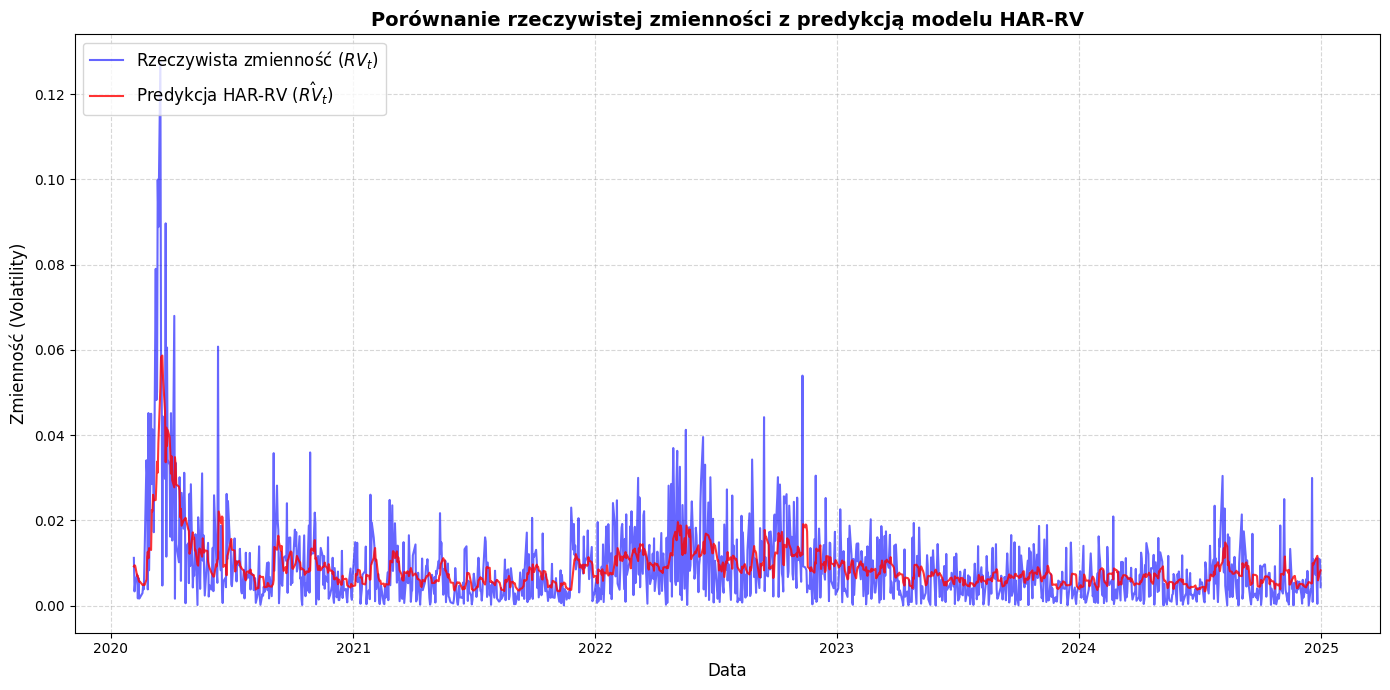

In [16]:
import matplotlib.pyplot as plt

df_model['RV_predicted'] = model.predict(X)

plt.figure(figsize=(14, 7))

plt.plot(df_model.index, df_model['RV_t'], label='Rzeczywista zmienność ($RV_t$)', color='blue', alpha=0.6, linewidth=1.5)

# Rysujemy predykcję modelu
plt.plot(df_model.index, df_model['RV_predicted'], label='Predykcja HAR-RV ($\hat{RV}_t$)', color='red', alpha=0.8, linewidth=1.5)

# Dodajemy elementy wykresu
plt.title('Porównanie rzeczywistej zmienności z predykcją modelu HAR-RV', fontsize=14, fontweight='bold')
plt.xlabel('Data', fontsize=12)
plt.ylabel('Zmienność (Volatility)', fontsize=12)
plt.legend(fontsize=12, loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)

# Automatyczne dopasowanie układu i wyświetlenie
plt.tight_layout()
plt.show()

In [20]:
def compute_rex_har_model_multi(data, ticker, alpha=0.05, sigma_window=22):
    """
    Dostosowana wersja funkcji dla danych z yfinance z MultiIndexem.
    Przekazujemy cały DataFrame oraz string z tickerem.
    """
    df = pd.DataFrame()
    
    # Wyciągamy cenę zamknięcia ('Close') dla konkretnego tickera z MultiIndexu
    df['Close'] = data[ticker]['Close']
    
    # Reszta algorytmu pozostaje bez zmian
    df['log_close'] = np.log(df['Close'])
    df['Ret_1d'] = df['log_close'].diff()
    
    df['sigma_t'] = df['Ret_1d'].rolling(window=sigma_window).std()
    
    f_inv_alpha = norm.ppf(alpha)
    f_inv_one_minus_alpha = norm.ppf(1 - alpha)
    
    df['r_threshold_minus'] = f_inv_alpha * df['sigma_t']
    df['r_threshold_plus'] = f_inv_one_minus_alpha * df['sigma_t']
    
    df['Ret_sq'] = df['Ret_1d'] ** 2
    
    df['REX_m_1d'] = np.where((df['Ret_1d'] > df['r_threshold_minus']) & (df['Ret_1d'] < df['r_threshold_plus']), 
                              df['Ret_sq'], 0)
    df['REX_plus_1d'] = np.where(df['Ret_1d'] >= df['r_threshold_plus'], df['Ret_sq'], 0)
    df['REX_minus_1d'] = np.where(df['Ret_1d'] <= df['r_threshold_minus'], df['Ret_sq'], 0)
    
    df['RV_t'] = df['Ret_sq']
    
    for comp in ['REX_m', 'REX_plus', 'REX_minus']:
        base_col = f'{comp}_1d'
        df[f'{comp}_lag1'] = df[base_col].shift(1)
        df[f'{comp}_bar5'] = df[base_col].shift(1).rolling(5).mean()
        df[f'{comp}_bar22'] = df[base_col].shift(1).rolling(22).mean()
        
    df.dropna(inplace=True)
    return df

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Przetwarzamy dane konkretnie dla S&P 500
prepared_df = compute_rex_har_model_multi(data, '^GSPC')

# 2. Wybieramy zmienne do scikit-learn
Y = prepared_df['RV_t']
X_cols = [
    'REX_plus_lag1', 'REX_plus_bar5', 'REX_plus_bar22',
    'REX_minus_lag1', 'REX_minus_bar5', 'REX_minus_bar22',
    'REX_m_lag1', 'REX_m_bar5', 'REX_m_bar22'
]
X = prepared_df[X_cols]

# 3. Podział chronologiczny (bez mieszania!)
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, shuffle=False)

# 4. Trening i predykcja
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# 5. Wyniki
print(f"MSE na zbiorze testowym dla ^GSPC: {mean_squared_error(y_test, y_pred):.6f}")
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")

MSE na zbiorze testowym dla ^GSPC: 0.000000
R2 Score: -0.6571


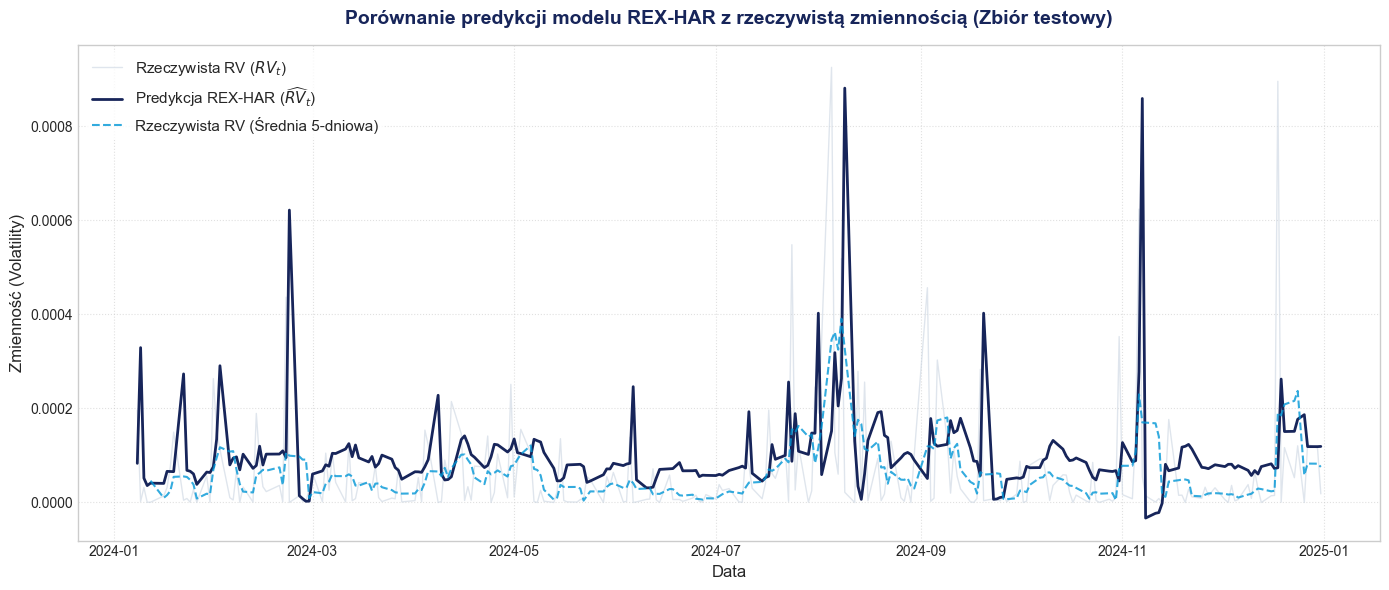

In [22]:
import matplotlib.pyplot as plt

# 1. Tworzymy DataFrame z wynikami (używając indeksu dat z y_test)
wykres_df = pd.DataFrame({
    'Rzeczywista RV': y_test,
    'Predykcja REX-HAR': y_pred
}, index=y_test.index)

# 2. Ustawienie stylu i wielkości wykresu (szeroki, idealny do prezentacji)
plt.style.use('seaborn-v0_8-whitegrid') # Czysty, profesjonalny styl tabelaryczny
plt.figure(figsize=(14, 6))

# 3. Rysowanie linii
plt.plot(wykres_df.index, wykres_df['Rzeczywista RV'], 
         label='Rzeczywista RV ($RV_t$)', color='#cbd5e1', alpha=0.6, linewidth=1)

plt.plot(wykres_df.index, wykres_df['Predykcja REX-HAR'], 
         label='Predykcja REX-HAR ($\widehat{RV}_t$)', color='#17255a', linewidth=2)

# 4. [Opcjonalnie] Dodanie wygładzonej linii dla rzeczywistej RV (np. 5-dniowa średnia), 
# żeby lepiej widzieć trend pod poszarpanymi danymi dziennymi
plt.plot(wykres_df.index, wykres_df['Rzeczywista RV'].rolling(5).mean(), 
         label='Rzeczywista RV (Średnia 5-dniowa)', color='#0096d6', linestyle='--', alpha=0.8, linewidth=1.5)

# 5. Personalizacja osi i tytułów (czcionki pod styl prezentacji z UJ)
plt.title('Porównanie predykcji modelu REX-HAR z rzeczywistą zmiennością (Zbiór testowy)', 
          fontsize=14, fontweight='bold', pad=15, color='#17255a')
plt.xlabel('Data', fontsize=12)
plt.ylabel('Zmienność (Volatility)', fontsize=12)

# 6. Dodanie legendy i siatki
plt.legend(fontsize=11, loc='upper left', frameon=True, facecolor='white', edgecolor='none')
plt.grid(True, linestyle=':', alpha=0.6)

# 7. Automatyczne dopasowanie i wyświetlenie/zapisanie wykresu
plt.tight_layout()
plt.savefig('predykcje_har_rex.png', dpi=300) # Zapisuje wykres w wysokiej jakości do prezentacji
plt.show()

--- WYNIKI DLA CAŁEGO ZBIORU (In-Sample) ---
Mean Squared Error (MSE): 0.000000
R-squared (R2 Score): 0.4983



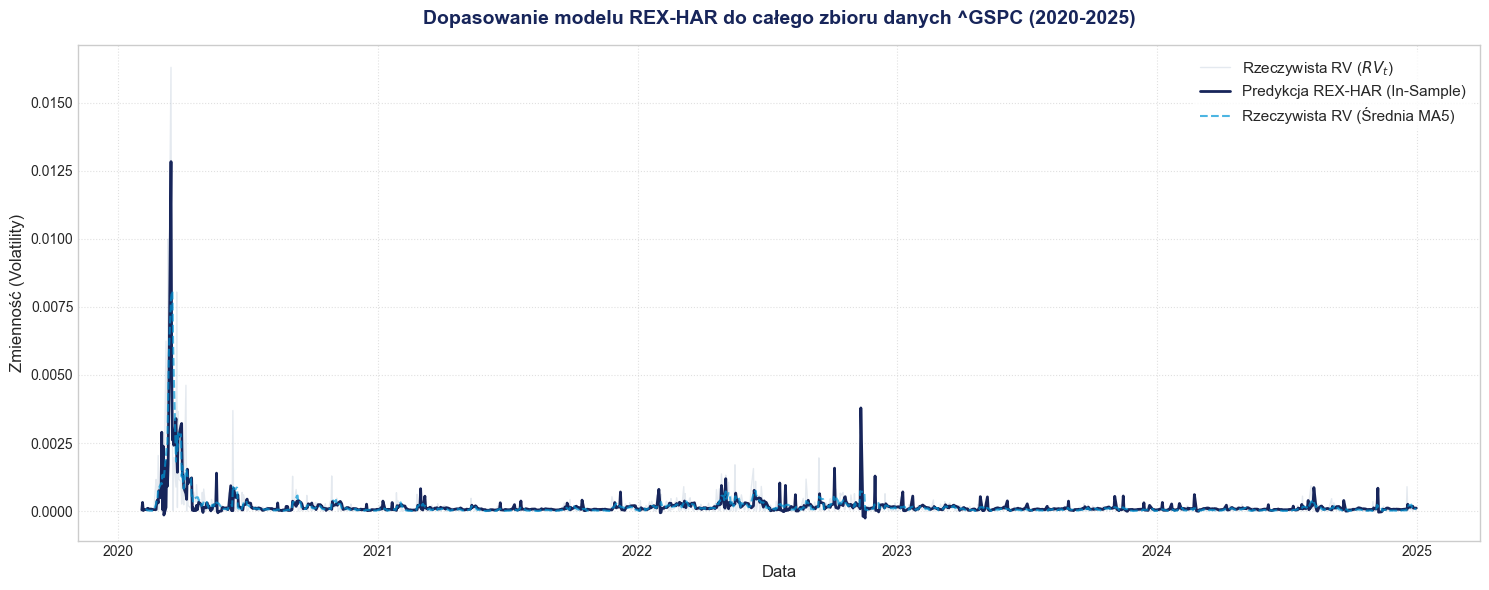

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Pobranie danych dla ^GSPC (cały dostępny okres)
prepared_df = compute_rex_har_model_multi(data, '^GSPC')

# 2. Definiujemy zmienne (cały zbiór)
Y = prepared_df['RV_t']
X_cols = [
    'REX_plus_lag1', 'REX_plus_bar5', 'REX_plus_bar22',
    'REX_minus_lag1', 'REX_minus_bar5', 'REX_minus_bar22',
    'REX_m_lag1', 'REX_m_bar5', 'REX_m_bar22'
]
X = prepared_df[X_cols]

# 3. Inicjalizacja i trening na CAŁOŚCI danych
model_all = LinearRegression()
model_all.fit(X, Y)

# 4. Predykcja in-sample (dla tych samych danych, na których trenowaliśmy)
y_pred_all = model_all.predict(X)

# 5. Statystyki dopasowania
mse_all = mean_squared_error(Y, y_pred_all)
r2_all = r2_score(Y, y_pred_all)

print("--- WYNIKI DLA CAŁEGO ZBIORU (In-Sample) ---")
print(f"Mean Squared Error (MSE): {mse_all:.6f}")
print(f"R-squared (R2 Score): {r2_all:.4f}\n")

# ==========================================
# 6. RYSOWANIE WYKRESU DLA CAŁEGO OKRESU
# ==========================================

wykres_all_df = pd.DataFrame({
    'Rzeczywista RV': Y,
    'Predykcja REX-HAR': y_pred_all
}, index=prepared_df.index)

plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(15, 6))

# Rzeczywiste dane (jasne tło, żeby nie zasłaniać trendu)
plt.plot(wykres_all_df.index, wykres_all_df['Rzeczywista RV'], 
         label='Rzeczywista RV ($RV_t$)', color='#cbd5e1', alpha=0.5, linewidth=1)

# Predykcja na całym zbiorze (ciemny granat)
plt.plot(wykres_all_df.index, wykres_all_df['Predykcja REX-HAR'], 
         label='Predykcja REX-HAR (In-Sample)', color='#17255a', linewidth=2)

# Wygładzona rzeczywista zmienność (średnia z 5 dni) dla lepszej czytelności kryzysów (np. COVID-19 w 2020)
plt.plot(wykres_all_df.index, wykres_all_df['Rzeczywista RV'].rolling(5).mean(), 
         label='Rzeczywista RV (Średnia MA5)', color='#0096d6', linestyle='--', alpha=0.7, linewidth=1.5)

plt.title('Dopasowanie modelu REX-HAR do całego zbioru danych ^GSPC (2020-2025)', 
          fontsize=14, fontweight='bold', pad=15, color='#17255a')
plt.xlabel('Data', fontsize=12)
plt.ylabel('Zmienność (Volatility)', fontsize=12)

plt.legend(fontsize=11, loc='upper right', frameon=True, facecolor='white', edgecolor='none')
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('predykcje_caly_zbior.png', dpi=300)
plt.show()

In [25]:
import numpy as np
import pandas as pd
import yfinance as yf
from scipy.stats import norm
from sklearn.linear_model import LinearRegression

tickers = ["^GSPC", "^IXIC", "^VIX"]

data = yf.download(
    tickers,
    start="2020-01-01",
    end="2025-01-01",
    auto_adjust=True
)
data = data.swaplevel(axis=1).sort_index(axis=1)

def prepare_har_rexq_data(data, ticker, rolling_window=252):
    df = data[ticker].copy()
    
    df['ret'] = np.log(df['Close'] / df['Close'].shift(1))
    df['RV'] = df['ret'] ** 2
    
    rolling_mean = df['ret'].rolling(window=rolling_window).mean()
    rolling_std = df['ret'].rolling(window=rolling_window).std()
    
    q_05 = rolling_mean + rolling_std * norm.ppf(0.05)
    q_95 = rolling_mean + rolling_std * norm.ppf(0.95)
    
    df['REXQ_minus'] = df['RV'] * (df['ret'] <= q_05).astype(int)
    df['REXQ_plus'] = df['RV'] * (df['ret'] >= q_95).astype(int)
    df['REXQ_m'] = df['RV'] * ((df['ret'] > q_05) & (df['ret'] < q_95)).astype(int)
    
    for col in ['REXQ_minus', 'REXQ_plus', 'REXQ_m']:
        df[f'{col}_lag1'] = df[col].shift(1)
        df[f'{col}_lag5_mean'] = df[col].shift(1).rolling(5).mean()
        df[f'{col}_lag22_mean'] = df[col].shift(1).rolling(22).mean()
        
    df = df.dropna()
    return df

def fit_har_rexq_sklearn(df):
    X_cols = [
        'REXQ_plus_lag1', 'REXQ_plus_lag5_mean', 'REXQ_plus_lag22_mean',
        'REXQ_minus_lag1', 'REXQ_minus_lag5_mean', 'REXQ_minus_lag22_mean',
        'REXQ_m_lag1', 'REXQ_m_lag5_mean', 'REXQ_m_lag22_mean'
    ]
    
    Y = df['RV'].values
    X = df[X_cols].values
    
    # scikit-learn automatycznie dodaje wyraz wolny (intercept), jeśli fit_intercept=True
    model = LinearRegression(fit_intercept=True)
    model.fit(X, Y)
    
    return model, X_cols

# Przykład użycia
df_gspc = prepare_har_rexq_data(data, "^GSPC")
model, feature_names = fit_har_rexq_sklearn(df_gspc)

# Wyświetlenie wyników w czytelnej formie
print(f"Wyraz wolny (Beta_0): {model.intercept_:.6f}\n")
print("Współczynniki dla poszczególnych zmiennych:")
for name, coef in zip(feature_names, model.coef_):
    print(f"{name}: {coef:.6f}")

[*********************100%***********************]  3 of 3 completed

Wyraz wolny (Beta_0): 0.000272

Współczynniki dla poszczególnych zmiennych:
REXQ_plus_lag1: 0.052219
REXQ_plus_lag5_mean: -0.046483
REXQ_plus_lag22_mean: 0.475919
REXQ_minus_lag1: -0.134695
REXQ_minus_lag5_mean: 0.227736
REXQ_minus_lag22_mean: 0.189268
REXQ_m_lag1: 0.066321
REXQ_m_lag5_mean: 0.236044
REXQ_m_lag22_mean: -2.554985


Wynik R^2 dla ^GSPC: 0.0124


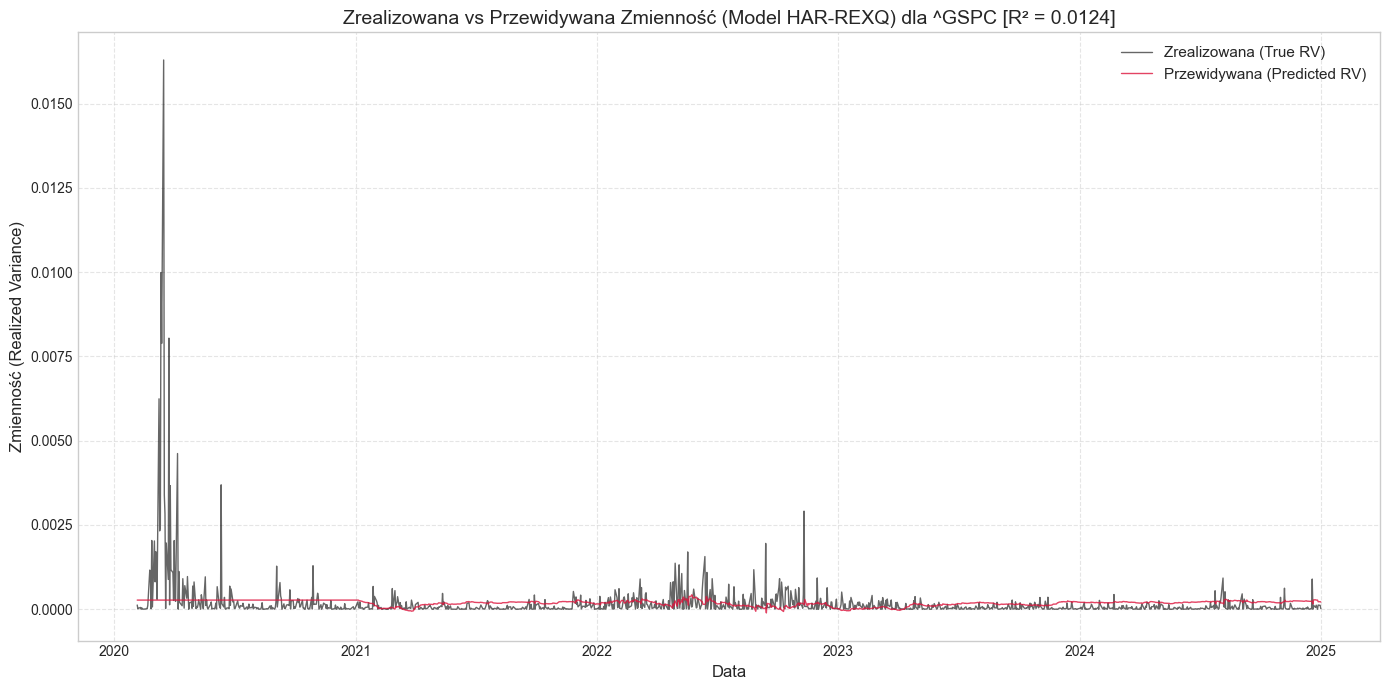

In [26]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

def evaluate_and_plot_har_rexq(df, model, feature_names, ticker_name):
    X = df[feature_names].values
    Y_true = df['RV'].values
    
    # Generowanie prognoz
    Y_pred = model.predict(X)
    
    # Obliczanie R^2
    r2 = r2_score(Y_true, Y_pred)
    print(f"Wynik R^2 dla {ticker_name}: {r2:.4f}")
    
    # Tworzenie wykresu
    plt.figure(figsize=(14, 7))
    plt.plot(df.index, Y_true, label='Zrealizowana (True RV)', color='black', alpha=0.6, linewidth=1)
    plt.plot(df.index, Y_pred, label='Przewidywana (Predicted RV)', color='crimson', alpha=0.8, linewidth=1)
    
    plt.title(f"Zrealizowana vs Przewidywana Zmienność (Model HAR-REXQ) dla {ticker_name} [R² = {r2:.4f}]", fontsize=14)
    plt.xlabel("Data", fontsize=12)
    plt.ylabel("Zmienność (Realized Variance)", fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

# Wywołanie dla S&P 500
evaluate_and_plot_har_rexq(df_gspc, model, feature_names, "^GSPC")